In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
%matplotlib inline

%load_ext autoreload
%autoreload 2

from kexp import atomdata
from waxa.plotting import *

font = 'DejaVu Sans'
# font = 'Helvetica Neue'
plt.rcParams['figure.dpi'] = 200
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font]
plt.rcParams['mathtext.fontset'] = 'custom'

In [ ]:
# ad = atomdata(0,3530)
ad=atomdata(0)
# ad = atomdata(23469,23469)
# plt.imshow(ad.od[5])

64584
[atomdata timing] load total=8.588s | get_data_file(initial)=7.770s | h5_open=0.018s | headers=0.155s | core_arrays=0.636s | datavault=0.004s | scope_data=0.000s
No ROI saved in run 64584 (cached).
Specify the new ROI.
[atomdata timing] init total=16.677s | load_data=8.589s | setup+roi=4.575s | unshuffle_old=0.000s | initial_analysis=3.513s


In [21]:
ad.save_roi_h5()
# ad.save_roi_excel('andor_tweezer')

In [19]:
ad.recrop()

No ROI saved in run 61608.
Specify the new ROI.


<Figure size 1280x960 with 0 Axes>

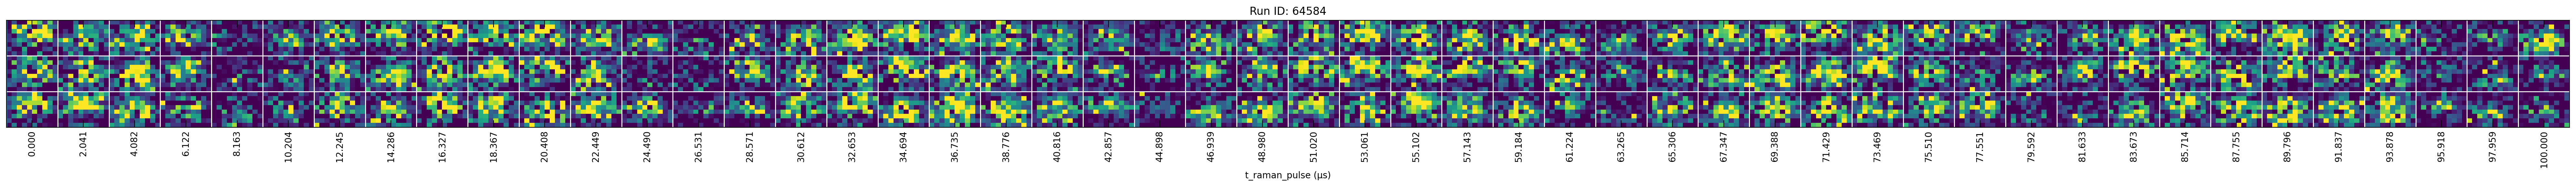

In [8]:
from waxa.plotting import plot_mixOD
plt.set_cmap("viridis")
plot_mixOD(ad,
           ad.od,
            max_od=2.,
            xvarformat='1.3f',
            figsize=[40,3.],
            lines=True,
            aspect='auto',
            swap_axes=False
            )
# plt.xticks(rotation=0)
plt.show()
# print(ad.experiment_code.)

In [114]:
ad.avg_repeats()

In [23]:
ad.revert_repeats()

In [253]:
print(ad.run_info.run_id)

45728


64584
Fit function: f(t) = A * exp(-t/tau) * (cos(Omega t / 2 + phi))**2 + B
Omega = 2*pi*55.54 kHz
 phi = 0.30552924068718823,
 A = 0.4727233610513197,
 B = 0.5099999999999999,
 tau = 53.98467157749423
pi time = 9.0029e-06 s
self.t_raman_pi_pulse = 9.003e-06


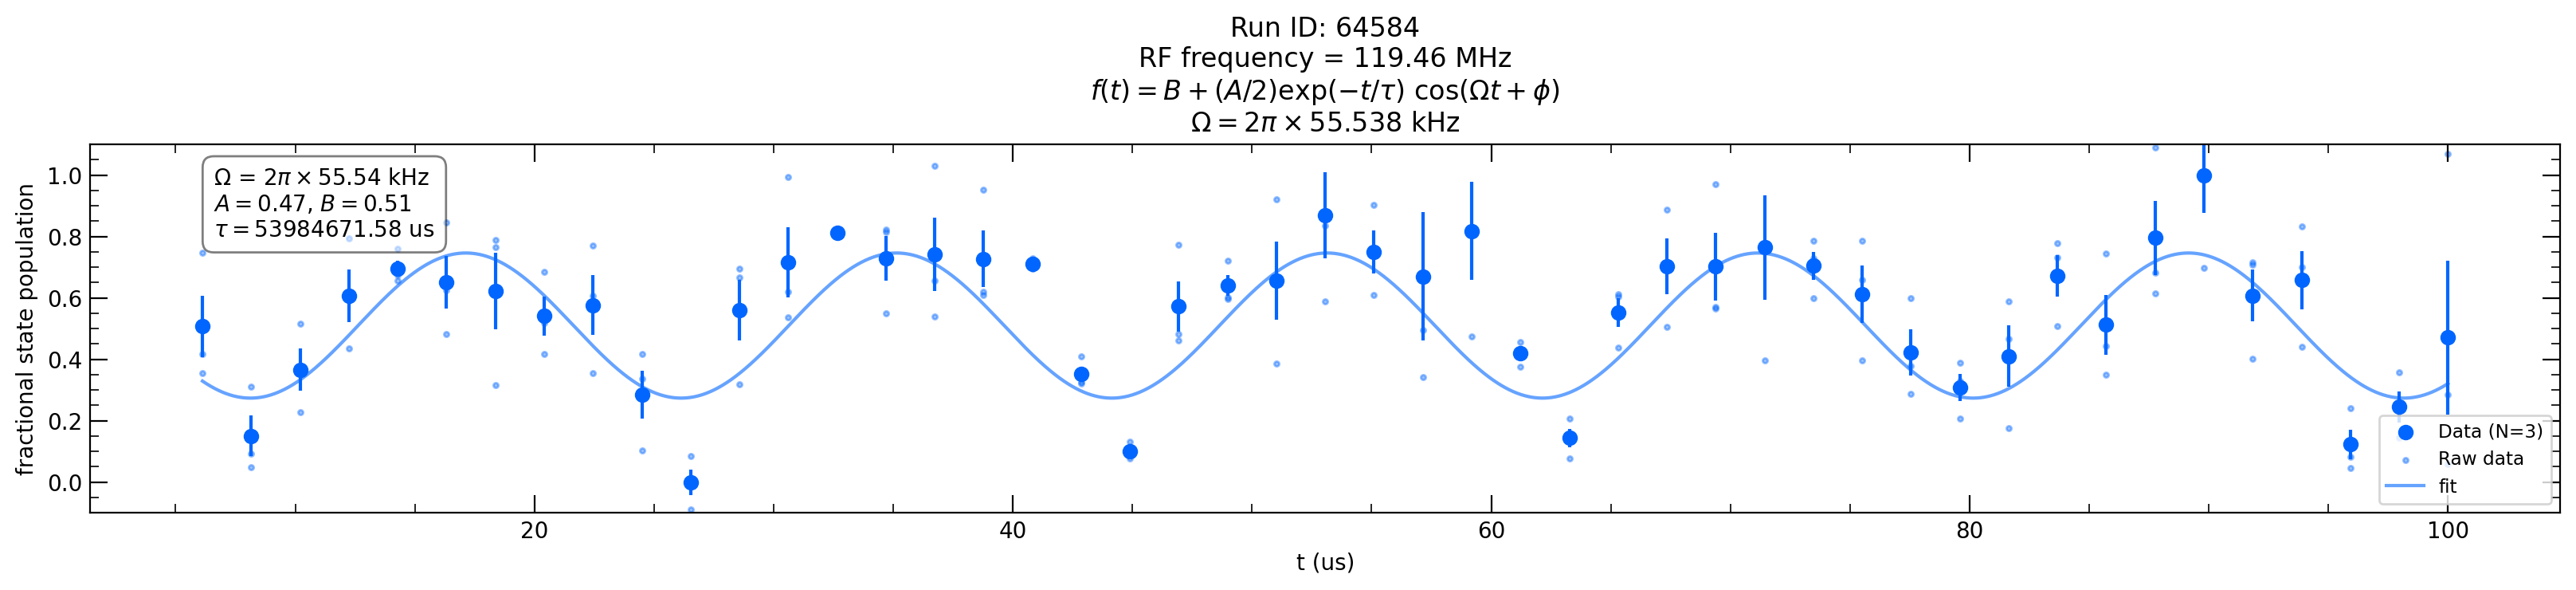

In [19]:
from waxa.plotting.standard_experiments import rabi_oscillation
print(ad.run_info.run_id)
# skip_last_N = 80
popt = rabi_oscillation(ad,rf_frequency_hz=ad.params.frequency_raman_transition,
                        include_idx=(3*ad.p.N_repeats,-1),
                         normalize_maximum_idx=None,
                         map_minimum_to_zero=True,
                         fit_guess_frequency=2*np.pi*50e3,
                         fit_guess_decay_tau=100.e-6,
                         fit_guess_phase=np.pi/2,
                         fit_guess_amp=.5,
                         figsize=(20,3),
                         fit_params_on_plot=True)
# )
# plt.ylim(-1.1,4.5)

print(f'self.t_raman_pi_pulse = {popt[0]:.3e}')